In [1]:
%load_ext autoreload
%autoreload 2
%cd ../../..
from rich import print



/Volumes/CrucialX/project-equinox


In [2]:
case_dir = "data/cases/LGAV_LFPG/"
batch_sgd_results_dir_path = f"{case_dir}results_full/"

In [3]:
# Look for the latest checkpoint in the `batch_sgd_results_dir_path`
import re
from pathlib import Path

def get_latest_checkpoint(results_dir_path):
    directory = Path(results_dir_path)
    
    # Pattern to match 'checkpoint_iter_X.pt' and capture X
    pattern = re.compile(r"checkpoint_iter_(\d+)\.pt")
    
    checkpoints = []
    
    # Iterate through files in the directory
    for file in directory.glob("checkpoint_iter_*.pt"):
        match = pattern.search(file.name)
        if match:
            iteration = int(match.group(1))
            checkpoints.append((iteration, file.name))
            
    if not checkpoints:
        return None
    
    # Sort by the iteration number (the first element of the tuple) and get the last one
    latest_checkpoint = max(checkpoints, key=lambda x: x[0])
    
    return latest_checkpoint[1]


latest_checkpoint_filename = batch_sgd_results_dir_path + get_latest_checkpoint(batch_sgd_results_dir_path)
print(f"Latest checkpoint: {latest_checkpoint_filename}")

Latest checkpoint: data/cases/LGAV_LFPG/results_full/checkpoint_iter_1001.pt

In [4]:
from equinox.posttrain import load_cost_model_parameters
from rich.console import Console
from rich.table import Table

def print_params_table(params_dict):
    console = Console()
    
    # Initialize the table
    table = Table(title="Common Parameters", show_header=True, header_style="bold magenta")
    
    table.add_column("Parameter", style="dim", width=12)
    table.add_column("Value", justify="right")

    # Add rows, formatting floats to 6 decimal places for clarity
    for key, value in params_dict.items():
        table.add_row(key, f"{value:.6f}")

    console.print(table)

params = load_cost_model_parameters(latest_checkpoint_filename)
print("[bold red]Parameters retrieved from learned cost model[/bold red]")
print_params_table(params["common"])
print(params["preference_matrix"].shape)  # (num_nodes, num_nodes)

Parameters retrieved from learned cost model

     Common Parameters      
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Parameter    ┃     Value ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ bias         │  0.064117 │
│ ac_dist      │ -0.000103 │
│ time         │ -0.001699 │
└──────────────┴───────────┘

torch.Size([600, 600])

Loading route graph from /Volumes/CrucialX/project-equinox/data/cases/LGAV_LFPG/graphs/routes.gml

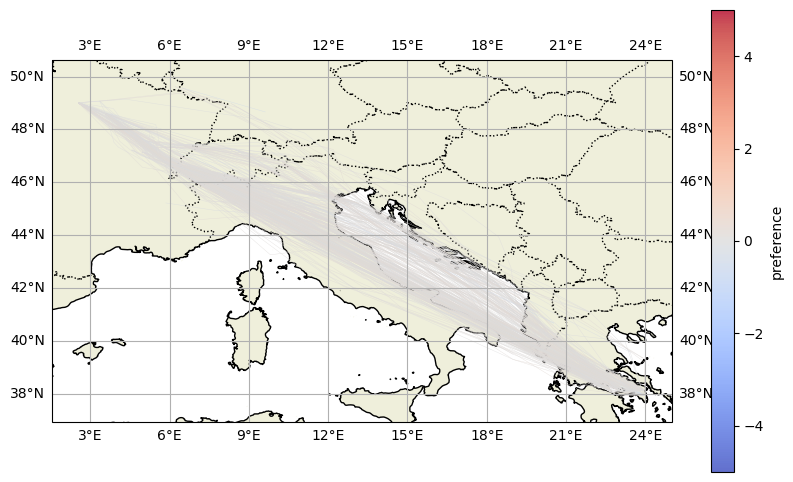

<GeoAxes: >

In [7]:
from equinox.posttrain import load_checkpoint_edge_preferences, plot_edge_preferences_cartopy

from pathlib import Path

def get_gml_path(batch_sgd_results_dir_path: str) -> str:
    """
    Recursively searches for a .gml file in the specified directory.
    Returns the absolute path to the .gml file.
    """
    directory = Path(batch_sgd_results_dir_path)
    
    # rglob("*.gml") searches recursively for all files ending in .gml
    # We use next() to get the first result since only one is guaranteed.
    try:
        gml_file = next(directory.rglob("*.gml"))
        return str(gml_file.absolute())
    except StopIteration:
        raise FileNotFoundError(f"No .gml file found in {batch_sgd_results_dir_path}")

gml_path = get_gml_path(case_dir)
print(f'Loading route graph from {gml_path}')

payload = load_checkpoint_edge_preferences(latest_checkpoint_filename, gml_path)
plot_edge_preferences_cartopy(
    payload["graph"],
    edge_preferences=payload["edge_preferences"],
    cmap="coolwarm",
    linewidth=0.3,
    alpha=0.8,
    percentile=0.5,
    percentile_mode="upper", # upper = more preferred, lower = less preferred, contrast = half lowest, half highest
    preference_color_range=(-5,5)
)

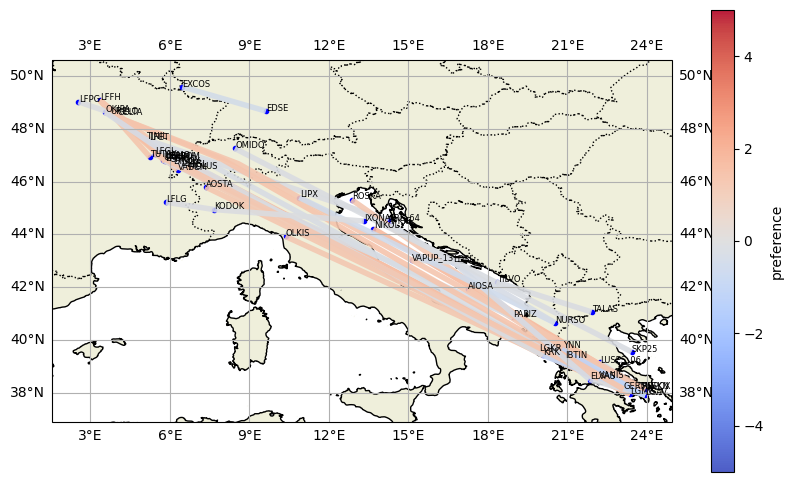

<GeoAxes: >

In [11]:
plot_edge_preferences_cartopy(
    payload["graph"],
    edge_preferences=payload["edge_preferences"],
    cmap="coolwarm",
    linewidth=4,
    alpha=0.9,
    percentile=0.02,
    percentile_mode="contrast", # upper = more preferred, lower = less preferred, contrast = half lowest, half highest
    preference_color_range=(-5,5),
    show_waypoints=True
)

# Raw prior route traversal frequency

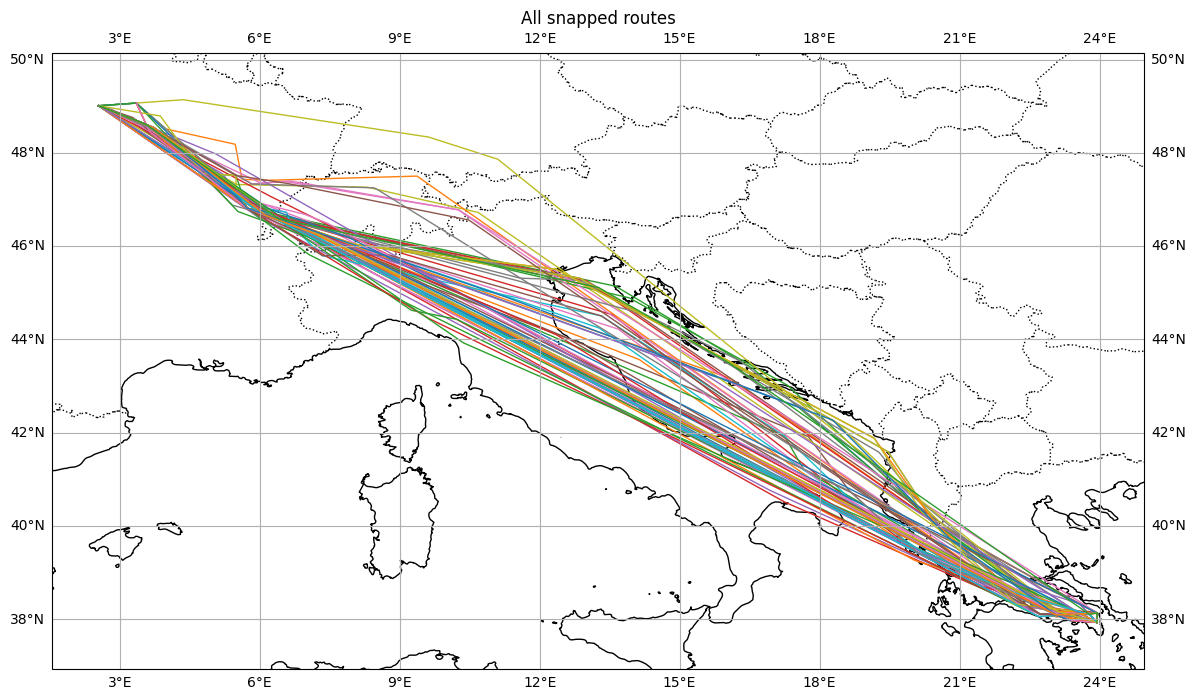

(<Figure size 1800x800 with 1 Axes>,
 <GeoAxes: title={'center': 'All snapped routes'}>)

In [12]:
from equinox.posttrain.plot_sample_routes import plot_snapped_routes
plot_snapped_routes(case_dir=Path("data/cases/LGAV_LFPG"), show_waypoints=False)

# Route cost decomposition and inspection

In [ ]:
from equinox.posttrain.cost_back_envelope import compute_route_cost_breakdown, breakdown_to_frame

reference_flight_id = "468D07SEH902"
reference_takeoff_timestamp = 1681366351

result = compute_route_cost_breakdown(
    checkpoint_path=latest_checkpoint_filename,
    case_dir=case_dir,
    flight_id=reference_flight_id,
    takeoff_time=reference_takeoff_timestamp
)

df = breakdown_to_frame(result["breakdown"])
print_params_table(result["totals"])
df


# Inference/Sampling

In [ ]:
from pathlib import Path 

from equinox.sampling.pipeline import compute_4d_path_for_dataset
from equinox.posttrain.plot_sample_routes import plot_sample_routes

res = compute_4d_path_for_dataset(
    case_dir=Path("data/cases/LGAV_LFPG"),
    checkpoint_path=Path(latest_checkpoint_filename),
    flight_id=reference_flight_id,
    takeoff_timestamp=reference_takeoff_timestamp,
    n_samples=200,
    policy="sample",
    output_dir=Path(f"data/cases/LGAV_LFPG/inference_flight_{reference_flight_id}"),
    seed=7,
)

In [ ]:

plot_sample_routes(
    case_dir=Path("data/cases/LGAV_LFPG"),
    routes_path=Path(f"data/cases/LGAV_LFPG/inference_flight_{reference_flight_id}/routes.txt"),
    show=True,
    show_waypoints=False,
    route_alpha=0.01,
    reference_flight_id=reference_flight_id,
    reference_takeoff_timestamp=reference_takeoff_timestamp,
    plot_wind = True,
    show_quiver = True,
    thickness = 10,
    plot_title=f"Inference for Flight {reference_flight_id}"
)

In [ ]:
from equinox.posttrain.cost_back_envelope import compute_routes_cost_breakdowns


compute_routes_cost_breakdowns(
    checkpoint_path=latest_checkpoint_filename,
    case_dir=case_dir,
    flight_id="46B825AEE612",
    takeoff_time="1682767235",
    routes_path=Path(f"data/cases/LGAV_LFPG/inference_flight_{reference_flight_id}/routes.txt"),
    limit=100
)